In [2]:
# standard python imports
import matplotlib.pylab as plt
import numpy as np

# tidy3D import
import tidy3d as td
import tidy3d.web as web
from tidy3d.constants import C_0
from tidy3d.plugins.mode import ModeSolver

09:14:12 Eastern Daylight Time ERROR: Failed to apply Tidy3D plotting style on  
                               import. Error: 'tidy3d.style' not found in the   
                               style library and input is not a valid URL or    
                               path; see `style.available` for list of available
                               styles                                           

In [3]:
# size of simulation domain
Lx, Ly, Lz = 15,15,15
dl = 0.05

# waveguide information
wg_width = 1.9
wg_height = 0.3
wg_permittivity = 4.58
sio2_permittivity = 2.0736 # this is the permittivity which is squar eof index (1.44)
si_permittivity = 12.11 #note that this is permittivity which is square of refractive index

# central frequency
wvl_um = 1.55
freq0 = C_0 / wvl_um
fwidth = freq0/100

# run_time in ps
run_time = 1e-12

# automatic grid specification
grid_spec = td.GridSpec.auto(min_steps_per_wvl=20, wavelength=wvl_um)

09:14:17 Eastern Daylight Time WARNING: Structure at 'structures[1]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.                                   

                               WARNING: Suppressed 1 WARNING message.           

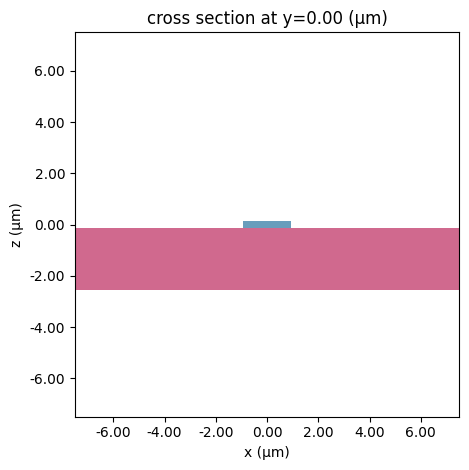

In [4]:
waveguide = td.Structure(
    geometry=td.Box(center=(0,0,0), size=(wg_width, td.inf, wg_height)),
    medium=td.Medium(permittivity=wg_permittivity),
)

# sio2 layer
sio2_layer = td.Structure(
    geometry=td.Box(center=(0, 0, -4.5 * wg_height), size=(15, td.inf, 8*wg_height)),
    medium=td.Medium(permittivity=sio2_permittivity),
)

# si layer
# si_layer = td.Structure(
#     geometry=td.Box(center=(0, 0, -7 * wg_height), size=(wg_width, td.inf, wg_height *6)),
#     medium=td.Medium(permittivity=si_permittivity),
# )

sim = td.Simulation(
    size=(Lx, Ly, Lz),
    grid_spec=grid_spec,
    structures=[waveguide, sio2_layer],
    run_time=run_time,
    boundary_spec=td.BoundarySpec.all_sides(boundary=td.Periodic()),
)

ax = sim.plot(y=0)
plt.show()

In [5]:
plane = td.Box(center=(0,wg_width*2, wg_height), size=(10, 0, 10))


In [6]:
mode_spec = td.ModeSpec(
    num_modes=3,
    target_neff=2.0,
)

In [7]:
num_freqs = 3
f0_ind = num_freqs // 2
freqs = np.linspace(freq0 - fwidth / 2, freq0 + fwidth / 2, num_freqs)


In [8]:
mode_solver = ModeSolver(
    simulation=sim,
    plane=plane,
    mode_spec=mode_spec,
    freqs=freqs,
)
mode_data = mode_solver.solve()

                               WARNING: Use the remote mode solver with subpixel
                               averaging for better accuracy through            
                               'tidy3d.web.run(...)' or the deprecated          
                               'tidy3d.plugins.mode.web.run(...)'.              

In [9]:
# mode_data.to_dataframe()


09:14:29 Eastern Daylight Time WARNING: Structure at 'structures[1]' has bounds 
                               that extend exactly to simulation edges. This can
                               cause unexpected behavior. If intending to extend
                               the structure to infinity along one dimension,   
                               use td.inf as a size variable instead to make    
                               this explicit.                                   

                               WARNING: Suppressed 1 WARNING message.           

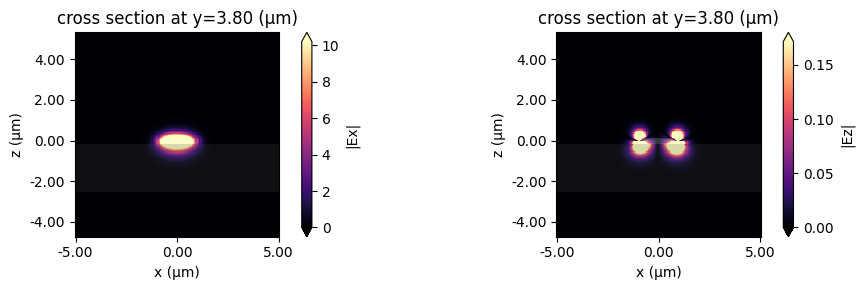

In [10]:
f, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 3))
mode_solver.plot_field("Ex", "abs", mode_index=0, f=freq0, ax=ax1)
mode_solver.plot_field("Ez", "abs", mode_index=0, f=freq0, ax=ax2)
plt.show()

In [11]:
lda0 = 1.55  # wavelength of interest
freq0 = td.C_0 / lda0  # frequency of interest
r_beam = 5.25  # beam radius
size = 6 * r_beam  # plane size for the beam profile

In [12]:
# generate a Gaussian beam
gaussian_beam = td.GaussianBeamProfile(
    waist_radius=r_beam,
    pol_angle=np.pi / 2,  # polarized in the y direction for coupling to the TE mode
    size=(size, size, 0),
    resolution=200,
    freqs=[freq0],
)

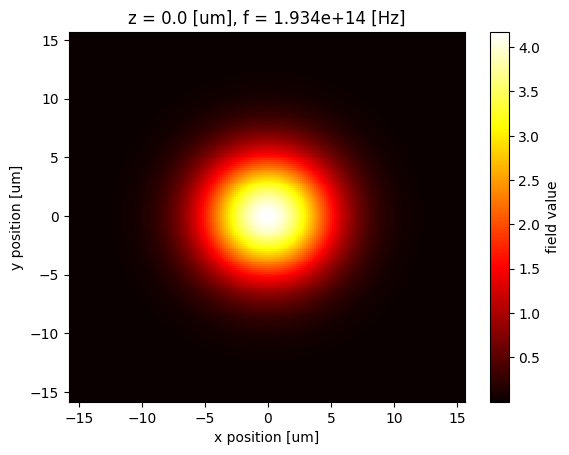

In [13]:
gaussian_beam.field_data.Ey.abs.plot(cmap="hot", x="x", y="y")
plt.show()

In [14]:
# # materials used
# si = td.material_library["cSi"]["Li1993_293K"]
# sio2 = td.material_library["SiO2"]["Horiba"]


def make_gaussian_beam(d):
    # waveguide = td.Structure(geometry=td.Box(center=(0, 0, 0), size=(h, w, td.inf)), medium=si)

    # generate a Gaussian beam
    gaussian_beam = td.GaussianBeamProfile(
    waist_radius=d/2,
    pol_angle=np.pi / 2,  # polarized in the y direction for coupling to the TE mode
    size=(10,0, 10),
    resolution=200,
    freqs=[freq0],


    )

    return gaussian_beam



In [15]:
d_list = np.linspace(0.1, 20, 50)
Ey_list = {f"d={d:.2f}": make_gaussian_beam(d).field_data for d in d_list}
Ey_list
d_list

array([ 0.1       ,  0.50612245,  0.9122449 ,  1.31836735,  1.7244898 ,
        2.13061224,  2.53673469,  2.94285714,  3.34897959,  3.75510204,
        4.16122449,  4.56734694,  4.97346939,  5.37959184,  5.78571429,
        6.19183673,  6.59795918,  7.00408163,  7.41020408,  7.81632653,
        8.22244898,  8.62857143,  9.03469388,  9.44081633,  9.84693878,
       10.25306122, 10.65918367, 11.06530612, 11.47142857, 11.87755102,
       12.28367347, 12.68979592, 13.09591837, 13.50204082, 13.90816327,
       14.31428571, 14.72040816, 15.12653061, 15.53265306, 15.93877551,
       16.34489796, 16.75102041, 17.15714286, 17.56326531, 17.96938776,
       18.3755102 , 18.78163265, 19.1877551 , 19.59387755, 20.        ])

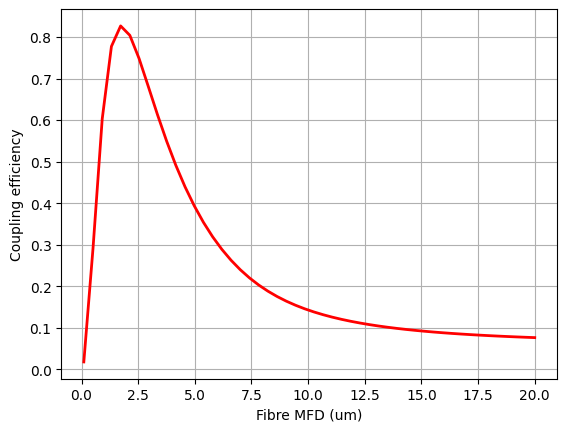

In [16]:
overlap = [
    mode_data.outer_dot(Ey_list[f"d={d:.2f}"]).squeeze()[-1] for d in d_list #values.squeeze()
]

plt.plot(d_list, np.abs(overlap) ** 2, "r", linewidth=2)
plt.xlabel("Fibre MFD (um)")
plt.ylabel("Coupling efficiency")
plt.grid()

In [17]:
print(np.abs(overlap) ** 2)

[0.01768024 0.29151096 0.60287727 0.77736833 0.82666668 0.80401865
 0.74843929 0.68132754 0.61328736 0.54919677 0.49100721 0.43921003
 0.3936059  0.35370609 0.3189316  0.2887021  0.26246989 0.23973058
 0.22002595 0.20294448 0.18812077 0.17523415 0.16400603 0.1541965
 0.14560039 0.13804309 0.13137654 0.12547536 0.12023352 0.11556127
 0.11138259 0.10763296 0.10425753 0.10120951 0.09844892 0.09594147
 0.09365769 0.09157214 0.08966282 0.08791061 0.08629889 0.08481312
 0.0834406  0.08217014 0.08099189 0.07989716 0.07887824 0.07792828
 0.0770412  0.07621156]


In [18]:
gaussian_field_aligned = gaussian_field.colocate(mode_data.monitor)
overlap = gaussian_field_aligned.normalized().overlap(mode_data.field.normalized())
efficiency = abs(overlap)**2


NameError: name 'gaussian_field' is not defined

In [ ]:
assert isinstance(gaussian_field, td.FieldData), f"gaussian_field is {type(gaussian_field)}"
assert isinstance(mode_data.monitor, td.ModeSolverMonitor), f"monitor is {type(mode_data.monitor)}"


In [22]:
import numpy as np

# Extract field components and coordinates
Ex = np.abs(mode_data.Ex[0].values[0])  # shape: (Nz, Nx)
Ey = np.abs(mode_data.Ey[0].values[0])
Ez = np.abs(mode_data.Ez[0].values[0])
x = np.array(mode_data.Ex[0].coords['x'])
z = np.array(mode_data.Ex[0].coords['z']).flatten()

# Compute total power density at each (z, x) point
power_density = Ex**2 + Ey**2 + Ez**2  # shape: (Nz, Nx)

# Integrate over z to get power profile along x
power_profile_x = np.sum(power_density, axis=0)  # shape: (Nx,)
power_profile_x /= np.sum(power_profile_x)  # normalize

# Compute cumulative power and find bounds
cumulative_power = np.cumsum(power_profile_x)
left_idx = np.searchsorted(cumulative_power, 0.005)
right_idx = np.searchsorted(cumulative_power, 0.995)
left_idx = np.clip(left_idx, 0, len(x) - 1)
right_idx = np.clip(right_idx, 0, len(x) - 1)

# Compute width
width_99 = x[right_idx] - x[left_idx]
print(f"Width containing 99% of total E-field power along x: {width_99:.3f} µm")


TypeError: len() of unsized object

In [57]:
import numpy as np

# Get the Ex field from mode_solver.data
Ex_field = mode_solver.data.field_components["Ex"]  # shape: (x, z) as xarray

# Convert to NumPy array
Ex_array = Ex_field.values  # shape: (x, z)

# Reconstruct x-grid manually
x_min, x_max = -5.0, 5.0  # adjust to match your simulation domain
nx = Ex_array.shape[0]
x = np.linspace(x_min, x_max, nx)

# Choose central z-slice
z_index = Ex_array.shape[1] // 2
Ex_line = Ex_array[:, z_index]  # now it's a proper 1D NumPy array

# Compute normalized power density
power_density = Ex_line**2
power_density /= np.sum(power_density)

# Cumulative power
cumulative_power = np.cumsum(power_density)

# Find indices for 0.5% and 99.5% thresholds
i_min = np.searchsorted(cumulative_power, 0.005)
i_max = np.searchsorted(cumulative_power, 0.995)

# Compute width
x_width_99 = x[i_max] - x[i_min]
print(f"Width containing 99% of mode power: {x_width_99:.3f} μm")


IndexError: index 181338 is out of bounds for axis 0 with size 208

In [28]:
mode_data = mode_solver.solve()


In [58]:
# choose a y value (center of y grid or 'y=0' etc). Here choose the y index nearest the center.
# Ex_field dims example: ('y','z')

# pick y coordinate (method 1): pick middle y index
y_coords = Ex_field.coords['y'].values
y_center_index = len(y_coords) // 2
Ex_y = Ex_field.isel(y=y_center_index)   # now dims ('z',)

# or method 2: pick nearest to some y value:
# Ex_y = Ex_field.sel(y=0.0, method='nearest')

power_1d = np.abs(Ex_y.values.squeeze())**2   # 1D along z
power_norm = power_1d / np.sum(power_1d)

x_coords = Ex_y.coords['z'].values
n = len(power_norm)

# find center index (peak along z)
center = int(np.argmax(power_norm))
left = center
right = center

# expand symmetrically until 99% contained (safe bounds)
while True:
    total_power = np.sum(power_norm[left:right+1])
    if total_power >= 0.99:
        break
    # expand left if possible, else only expand right
    if left > 0:
        left -= 1
    if right < n - 1:
        right += 1
    # if both bounds reached, break to avoid infinite loop
    if left == 0 and right == n - 1:
        break

x_width_99 = x_coords[right] - x_coords[left]
print(f"Symmetric X-width containing 99% of Ex power: {x_width_99:.6f} μm")


IndexError: index 141603 is out of bounds for axis 0 with size 152

In [74]:
import numpy as np
import xarray as xr

def x_width_99_central_slice(Ex_field, target_fraction=0.9999):
    """
    Compute x-width containing >= target_fraction of |Ex|^2 along x,
    using the central slice in y, z, first f and first mode_index.
    Peak will be at the physical center if waveguide is symmetric.
    """
    debug = {}
    if not isinstance(Ex_field, xr.DataArray):
        raise TypeError("Ex_field must be an xarray.DataArray with dims ('x','y','z','f','mode_index')")

    # pick central slice along y and z, first f, first mode_index
    x_slice = Ex_field.isel(
        y=len(Ex_field.coords['y'])//2,
        z=len(Ex_field.coords['z'])//2,
        f=0,
        mode_index=0
    )
    debug['x_slice_shape'] = x_slice.shape

    # 1D power profile along x
    p = np.abs(x_slice.values.squeeze())**2
    x_coords = x_slice.coords['x'].values
    n = len(p)

    # normalize
    p_norm = p / np.sum(p)

    # find peak
    center = np.argmax(p_norm)
    left = center
    right = center

    # expand symmetrically until target_fraction is enclosed
    while True:
        left_clamped = max(0, left)
        right_clamped = min(n-1, right)
        enclosed = np.sum(p_norm[left_clamped:right_clamped+1])
        if enclosed >= target_fraction:
            left, right = left_clamped, right_clamped
            break
        if left > 0:
            left -= 1
        if right < n-1:
            right += 1
        if left <= 0 and right >= n-1:
            left, right = 0, n-1
            break

    x_left = x_coords[left]
    x_right = x_coords[right]
    width = float(x_right - x_left)
    enclosed_fraction = float(np.sum(p_norm[left:right+1]))
    debug.update({
        'center_index': center,
        'x_left_index': left,
        'x_right_index': right,
        'x_left': x_left,
        'x_right': x_right,
        'enclosed_fraction': enclosed_fraction
    })

    return width, x_left, x_right, debug

# -------------------------
# Use the function with your Ex_field
# -------------------------
if 'Ex_field' not in globals():
    raise RuntimeError("Variable 'Ex_field' not found in globals. Assign your Ex_field and re-run.")

x_width_99, xL, xR, dbg = x_width_99_central_slice(Ex_field)
print(f"x_width_99 (99% of |Ex|^2) = {x_width_99:.6f} µm")
print(f"x_left = {xL:.6f}, x_right = {xR:.6f}")
print("Debug info:", dbg)


x_width_99 (99% of |Ex|^2) = 2.627134 µm
x_left = -1.340348, x_right = 1.286786
Debug info: {'x_slice_shape': (208,), 'center_index': 103, 'x_left_index': 69, 'x_right_index': 137, 'x_left': -1.3403478961963566, 'x_right': 1.2867857039893948, 'enclosed_fraction': 0.9999357848199175}
